# 🦷 Phase 1: YOLOv8 Dental Detector Training & Evaluation

This notebook trains and evaluates the YOLOv8 object detection model on dental images to detect:
- **Class 0**: `healthy`
- **Class 1**: `plaque`
- **Class 2**: `caries`

In [14]:
# 1. Set Working Directory & Verify GPU
%matplotlib inline
import os
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml
from IPython.display import Image, display

# Ensure current working directory is the repo root
if Path.cwd().name == 'notebooks':
    os.chdir('..')

REPO_ROOT = Path.cwd().resolve()
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

print(f'Working Directory : {REPO_ROOT}')
print(f'PyTorch Version   : {torch.__version__}')
print(f'CUDA Available    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU Device Name   : {torch.cuda.get_device_name(0)}')
    props = torch.cuda.get_device_properties(0)
    print(f'Total VRAM        : {props.total_memory / 1e9:.2f} GB')

Working Directory : C:\Users\user\Downloads\dental-model
PyTorch Version   : 2.5.1+cu121
CUDA Available    : True
GPU Device Name   : NVIDIA GeForce RTX 4070
Total VRAM        : 12.88 GB


In [15]:
# 2. Inspect Dataset Config
data_yaml_path = Path('data/processed/detector/data.yaml').resolve()
with open(data_yaml_path) as f:
    data_cfg = yaml.safe_load(f)

print('Dataset Configuration:')
print(yaml.dump(data_cfg, default_flow_style=False))

for split in ['train', 'val', 'test']:
    n_imgs = len(list(Path(f'data/processed/detector/{split}/images').glob('*.*')))
    print(f'  • {split.upper():5s} set : {n_imgs:,} images')

Dataset Configuration:
names:
- healthy
- plaque
- caries
nc: 3
path: C:/Users/user/Downloads/dental-model/data/processed/detector
test: test/images
train: train/images
val: val/images

  • TRAIN set : 4,881 images
  • VAL   set : 692 images
  • TEST  set : 615 images


## 3. 🚀 YOLOv8 Training (Optional - already completed)
Only run this cell if you want to re-train from scratch.

In [16]:
# 3. Run YOLOv8 Training (Single source of truth via src/dental_model/detector/train.py)
from dental_model.detector.train import train

# Executes training using the centralized config with fixed seeds and CUDA device management
best_weights = train(config_path='configs/detector_v1.yaml')
print(f'\n✅ Training complete! Best checkpoint saved at: {best_weights}')

2026-08-22 18:01:26,848 [INFO] dental_model.detector.train: Seeds fixed to 42
2026-08-22 18:01:26,848 [INFO] dental_model.detector.train: Training device: cuda
2026-08-22 18:01:26,850 [INFO] dental_model.detector.train: Loading model: yolov8s.pt (pretrained=True)
2026-08-22 18:01:26,890 [INFO] dental_model.detector.train: Starting YOLO training with kwargs: {'data': 'C:\\Users\\user\\Downloads\\dental-model\\data\\processed\\detector\\data.yaml', 'epochs': 100, 'imgsz': 640, 'batch': 16, 'patience': 30, 'device': 'cuda', 'seed': 42, 'optimizer': 'auto', 'lr0': 0.01, 'workers': 4, 'project': 'C:\\Users\\user\\Downloads\\dental-model\\models\\detector_runs', 'name': 'v1', 'pretrained': True, 'exist_ok': True, 'verbose': True}
Ultralytics 8.4.126  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070, 12282MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, 

## 4. 📊 Training Metrics Table (`results.csv`)
Reads and displays the exact numerical metrics logged at each epoch.

In [17]:
results_csv = Path('models/detector_runs/v1/results.csv')
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]
    cols = [
        'epoch', 'train/box_loss', 'train/cls_loss',
        'val/box_loss', 'val/cls_loss',
        'metrics/precision(B)', 'metrics/recall(B)',
        'metrics/mAP50(B)', 'metrics/mAP50-95(B)'
    ]
    display_cols = [c for c in cols if c in df.columns]
    print(f'Total Epochs Completed: {len(df)}')
    print('\nFirst 5 & Last 5 Epochs:')
    display(pd.concat([df[display_cols].head(5), df[display_cols].tail(5)]))
else:
    print('results.csv not found.')

Total Epochs Completed: 50

First 5 & Last 5 Epochs:


,epoch,train/box_loss,train/cls_loss,val/box_loss,val/cls_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
0,1,1.70891,2.92107,2.17832,5.26471,0.17632,0.20341,0.13396,0.06184
1,2,1.72423,2.50606,2.06404,3.51282,0.23759,0.23359,0.20273,0.10296
2,3,1.72942,2.37389,2.10479,3.49924,0.21195,0.22350,0.18749,0.08866
3,4,1.71378,2.28994,2.08026,3.54812,0.24789,0.25915,0.17887,0.08490
4,5,1.68298,2.21527,2.01059,2.92781,0.24262,0.25369,0.20809,0.09950
45,46,1.34868,1.29366,1.76638,2.03409,0.44538,0.48034,0.41374,0.22864
46,47,1.34268,1.26845,1.76554,2.14221,0.43102,0.48497,0.40733,0.23021
47,48,1.33352,1.25385,1.76968,2.10979,0.44916,0.49726,0.42982,0.23868
48,49,1.32706,1.24411,1.76511,2.09142,0.45474,0.49413,0.41977,0.23449
49,50,1.32707,1.22302,1.76566,2.04943,0.45601,0.48878,0.42669,0.23722


## 5. 📈 Training & Validation Curves
Displays the multi-panel training loss and mAP graph generated by YOLOv8.

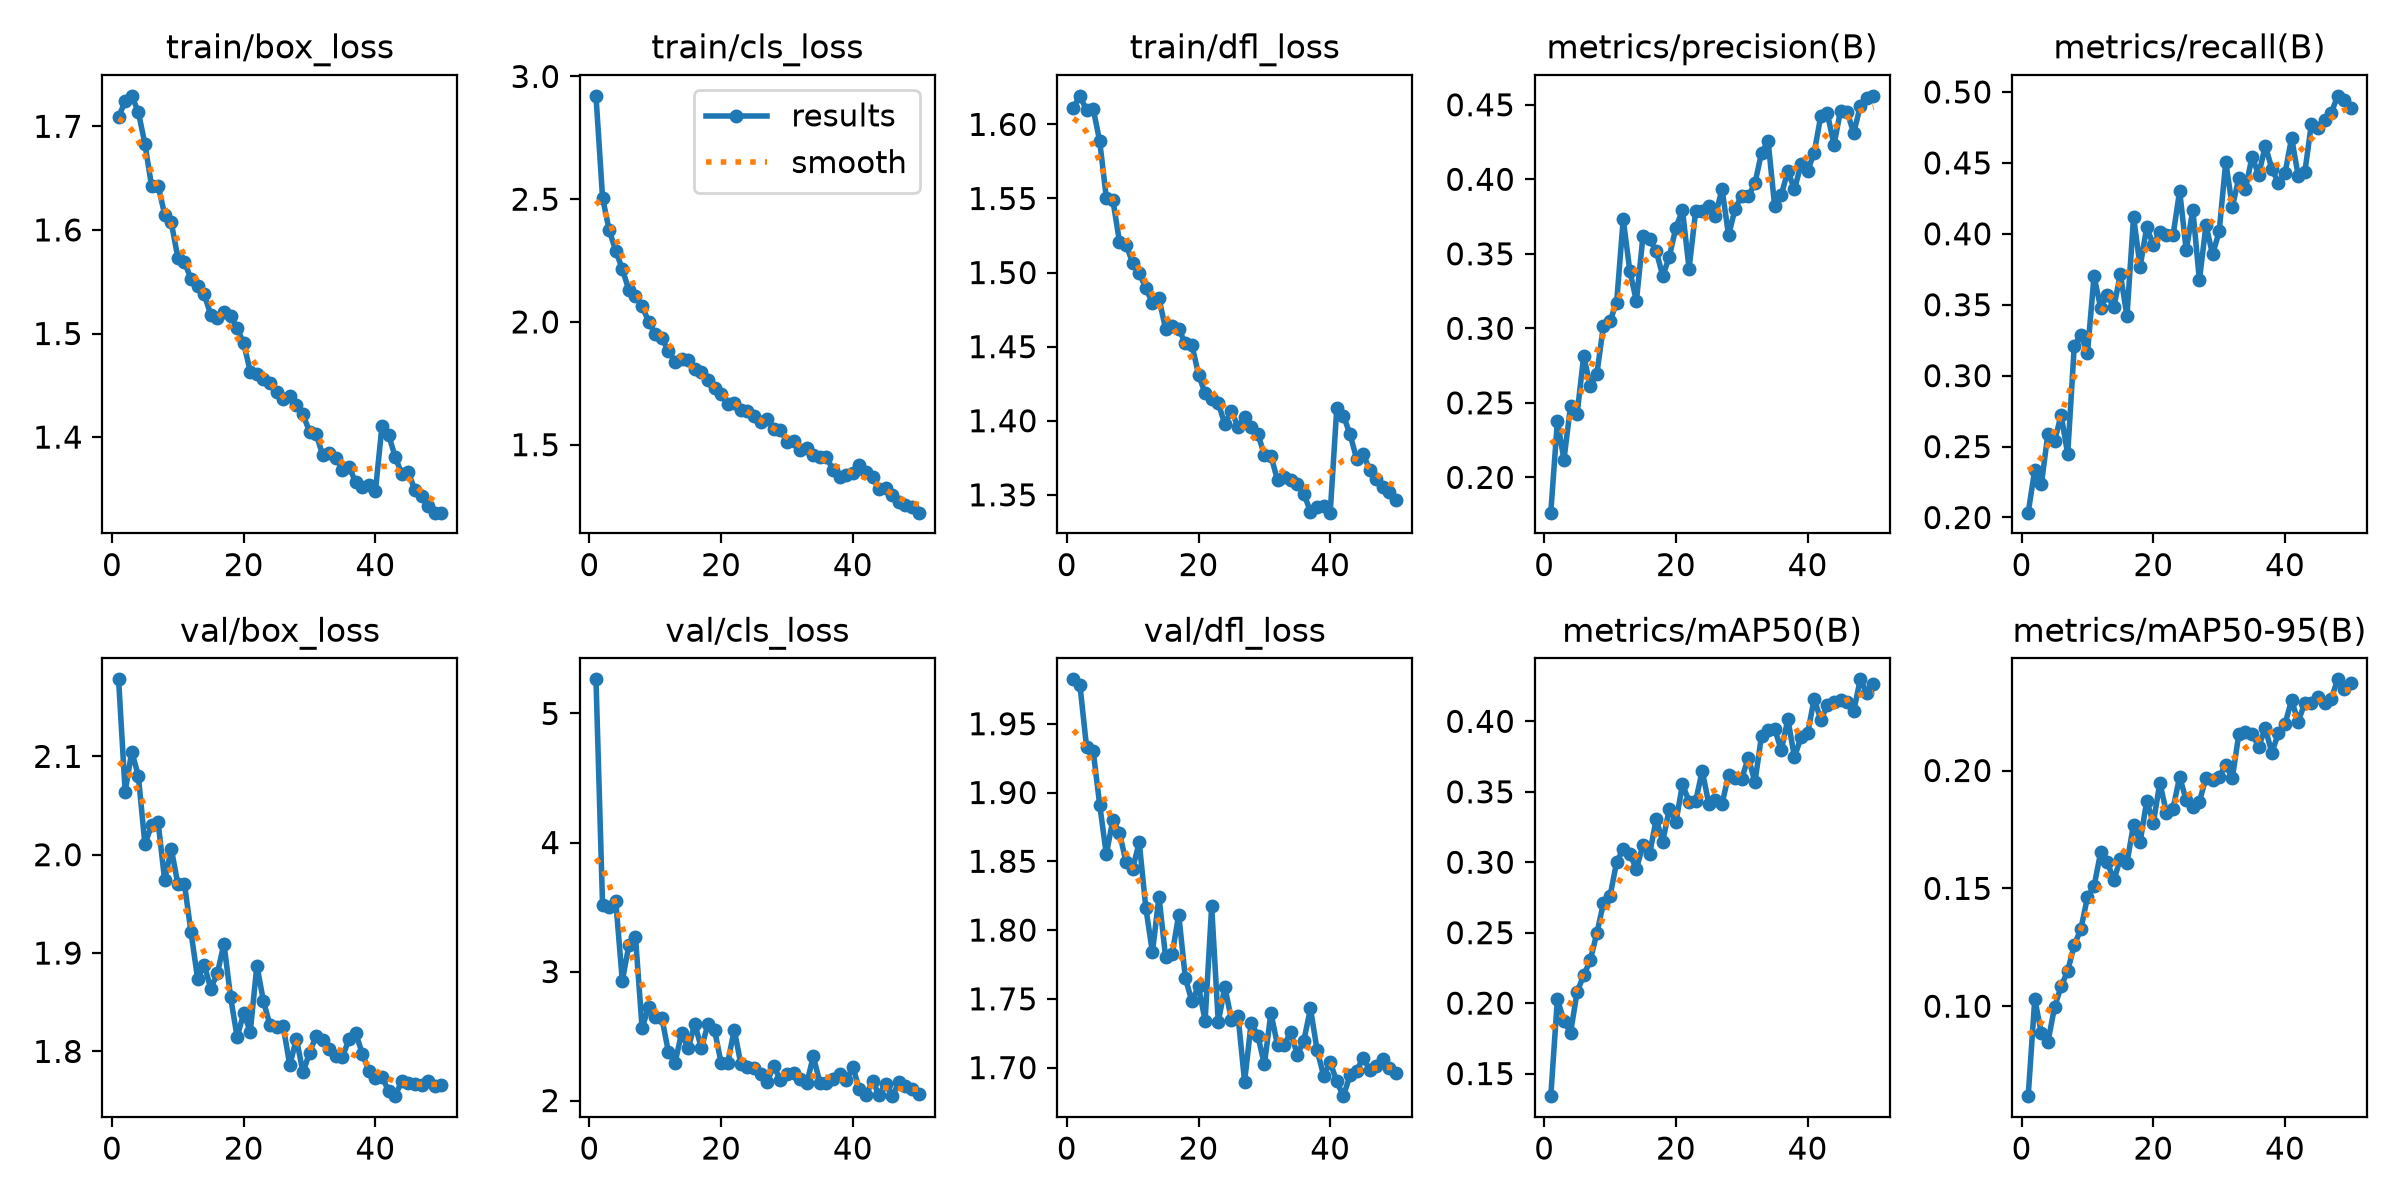

In [18]:
results_img = Path('models/detector_runs/v1/results.png')
if results_img.exists():
    display(Image(filename=str(results_img)))
else:
    print('results.png not found.')

## 6. 🎯 Validation Confusion Matrix

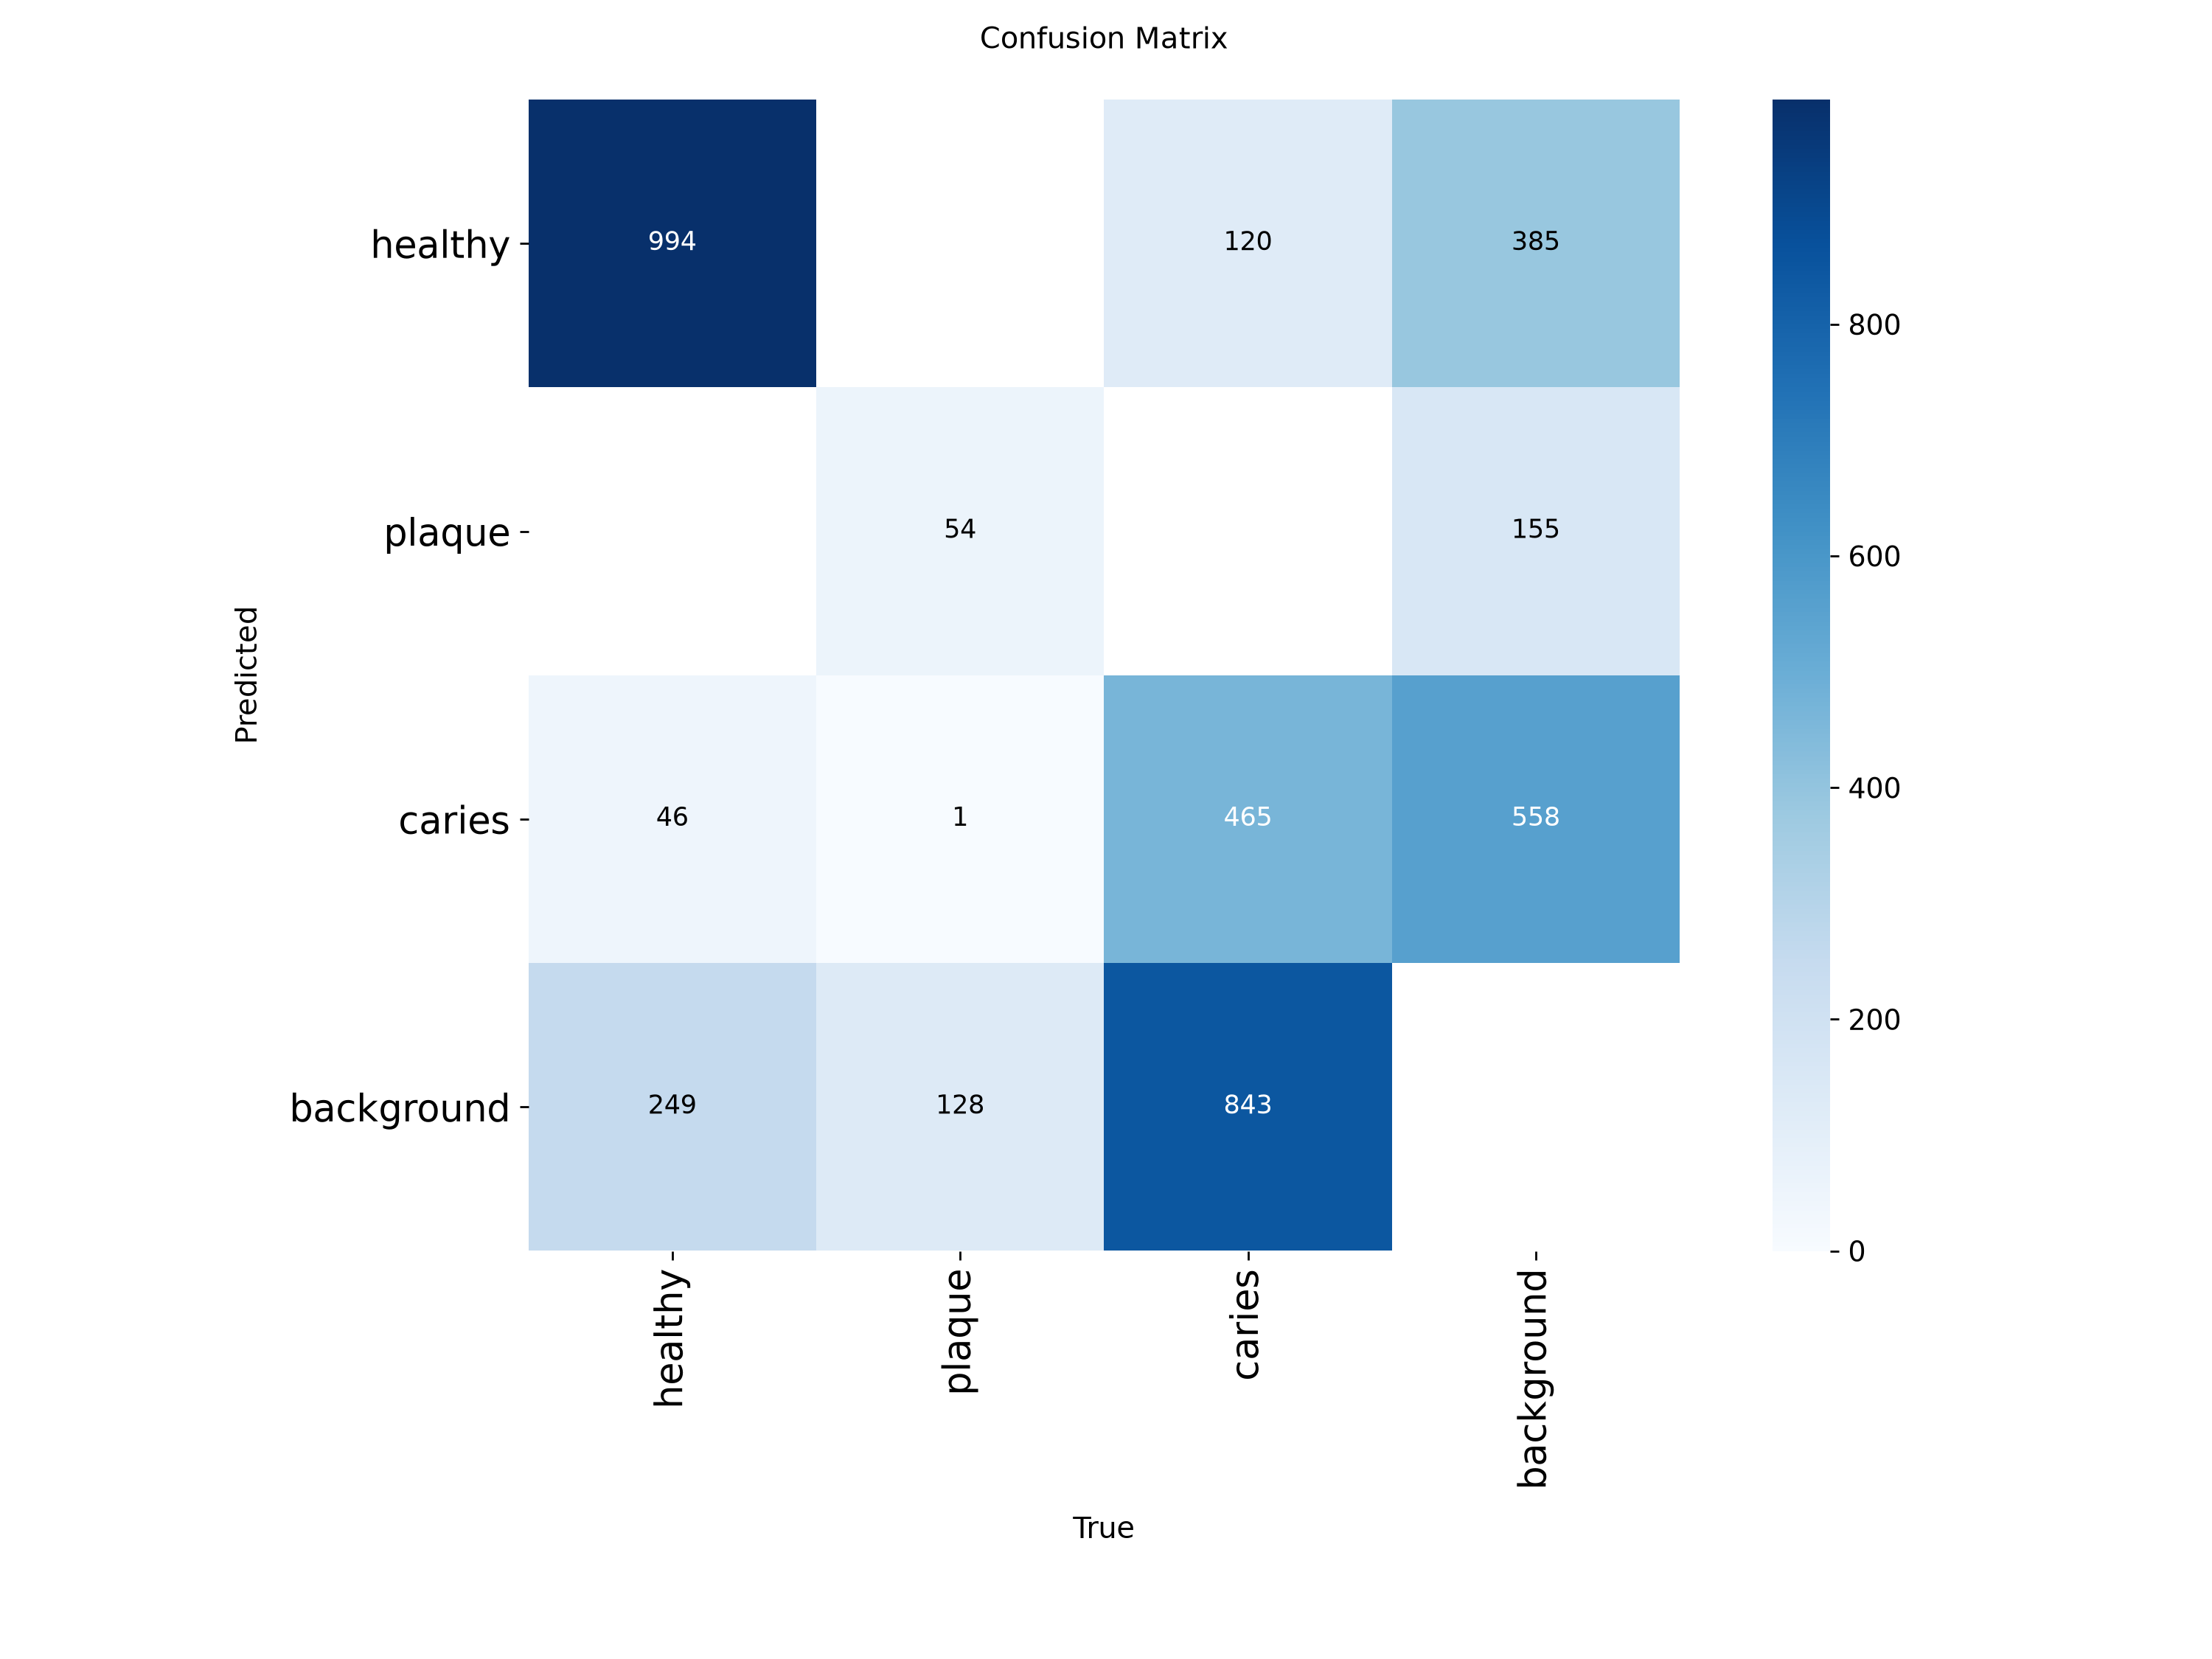

In [19]:
cm_img = Path('models/detector_runs/v1/confusion_matrix.png')
if cm_img.exists():
    display(Image(filename=str(cm_img)))
else:
    print('confusion_matrix.png not found.')

## 7. 🔍 Visual Bounding Box Detections on Test Images
Runs `DentalDetector` on sample test images and draws color-coded detection boxes.

2026-08-22 18:59:46,702 [INFO] dental_model.detector.infer: Loading detector from C:\Users\user\Downloads\dental-model\models\detector_runs\v0\weights\best.pt on device 'cuda'


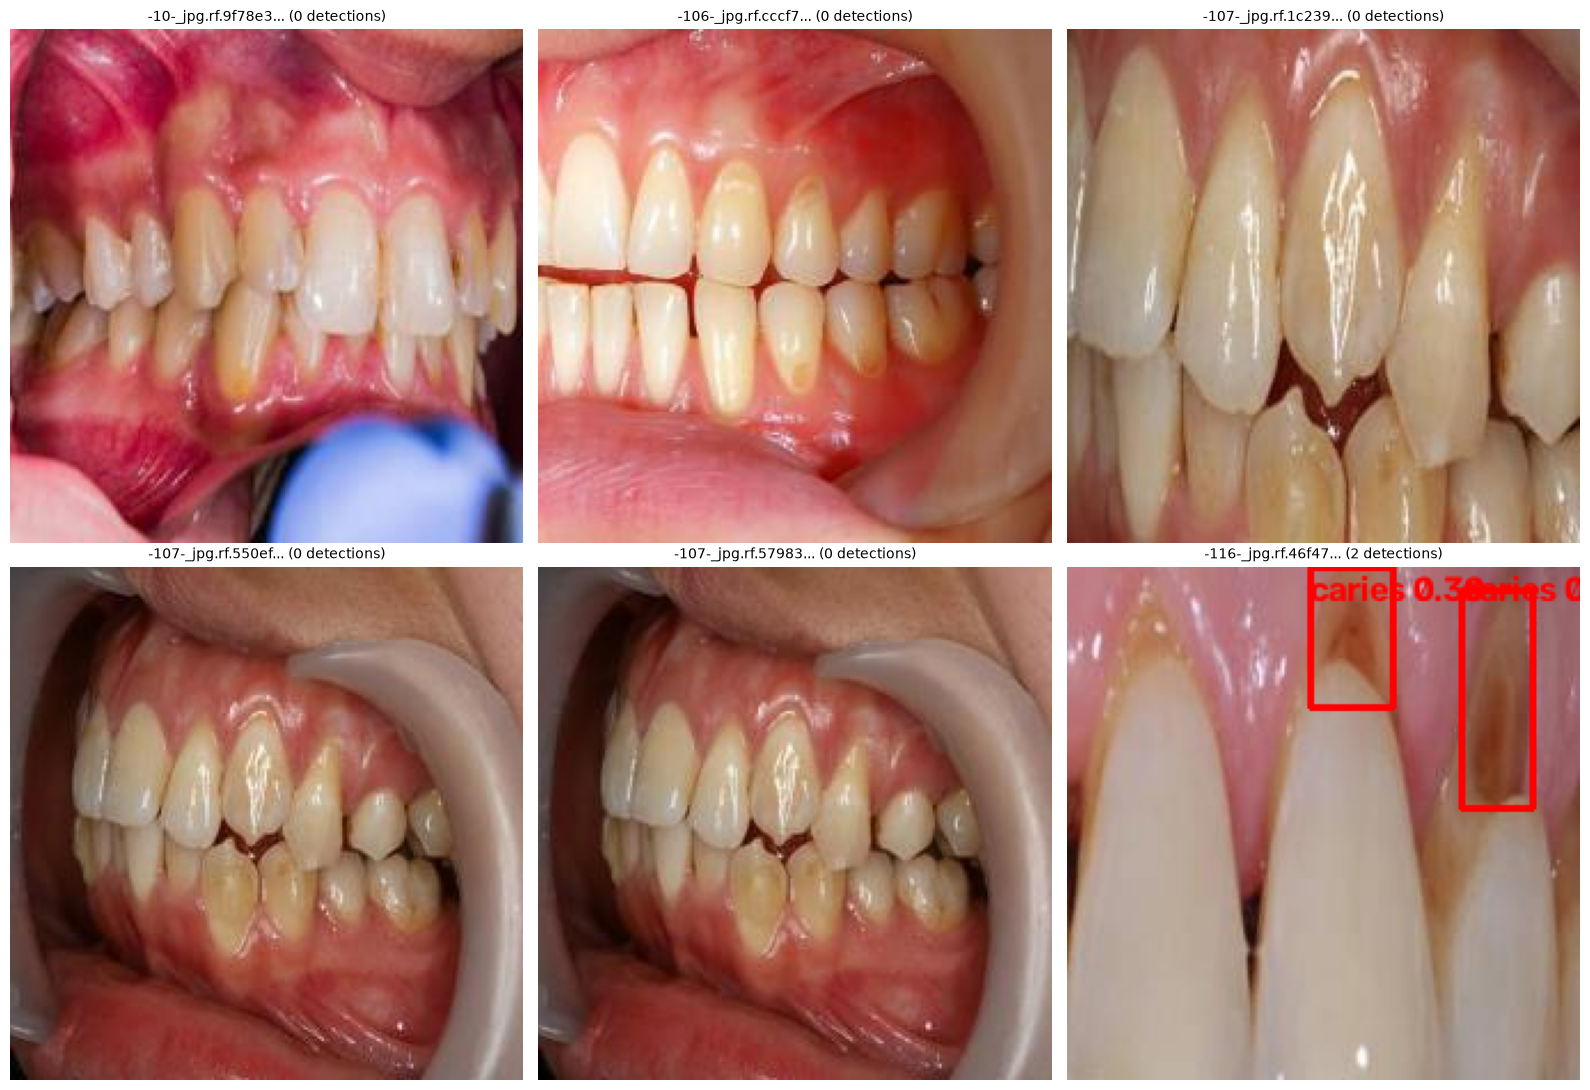

In [20]:
from dental_model.detector.infer import DentalDetector

best_weights = Path('models/detector_runs/v1/weights/best.pt')
if best_weights.exists():
    detector = DentalDetector(weights_path=best_weights, conf_threshold=0.25, iou_threshold=0.45)
    test_images = list(Path('data/processed/detector/test/images').glob('*.jpg'))[:6]

    fig, axes = plt.subplots(2, 3, figsize=(16, 11))
    axes = axes.flatten()

    for idx, img_p in enumerate(test_images):
        dets = detector.predict(img_p)
        img = cv2.imread(str(img_p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        for det in dets:
            x1, y1, x2, y2 = [int(v) for v in det['bbox']]
            cls_name = det['class_name']
            conf = det['confidence']
            color = (
                (0, 255, 0) if cls_name == 'healthy'
                else (255, 165, 0) if cls_name == 'plaque'
                else (255, 0, 0)
            )
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, f'{cls_name} {conf:.2f}', (x1, max(15, y1 - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        axes[idx].imshow(img)
        axes[idx].set_title(f'{img_p.name[:18]}... ({len(dets)} detections)', fontsize=10)
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('No weights found at models/detector_runs/v1/weights/best.pt')